# Targets

This notebook is strictly for target construction and target plots. It rebuilds the feature set only to get the reference price and short implied-vol proxy needed for forward targets.

Default bucket size is 5 minutes.

In [1]:
from __future__ import annotations

import os
import sys
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns

if "notebooks" not in sys.path:
    sys.path.append("notebooks")

from advanced_features import (
    build_feature_set,
    build_targets,
    discover_datasets,
)

ROOT = Path(os.environ.get("MODL_WS_NORMALIZED_DIR", "/mnt/burner-archive/ws_normalized")).expanduser()
DATE = os.environ.get("MODL_VIEW_DATE", "2026-06-30")
DATE_TAG = datetime.strptime(DATE, "%Y-%m-%d").strftime("%y-%m-%d")
FEATURE_ROOT = Path(os.environ.get("MODL_WS_FEATURE_DIR", "/mnt/burner-archive/ws_features")).expanduser()
BAR_MINUTES = int(os.environ.get("MODL_BAR_MINUTES", "5"))
HORIZONS = (5, 15, 30)
SAVE_OUTPUTS = False

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 240)
pd.set_option("display.max_colwidth", 180)
pl.Config.set_tbl_cols(240)
pl.Config.set_tbl_rows(24)

DATASETS = discover_datasets(ROOT, DATE_TAG)
if not DATASETS:
    raise FileNotFoundError(f"No normalized Parquet files found under {ROOT} for {DATE}")

ROOT, DATE, DATE_TAG, BAR_MINUTES, len(DATASETS)


(PosixPath('/mnt/burner-archive/ws_normalized'),
 '2026-06-30',
 '26-06-30',
 5,
 14)

## Build Feature Set And Targets

In [2]:
feature_set = build_feature_set(DATASETS, horizons=HORIZONS, bar_minutes=BAR_MINUTES)
feature_matrix = feature_set.feature_matrix
base_feature_matrix = feature_set.base_feature_matrix
trade_features = feature_set.trade_features
book_features = feature_set.book_features
deribit_option_features = feature_set.deribit_option_features
term_structure_features = feature_set.term_structure
option_smile_features = feature_set.option_smile
futures_basis_features = feature_set.futures_basis
funding_features = feature_set.funding_features
rv_features = feature_set.rv_features
reference_price = feature_set.reference_price

df = feature_matrix
df_stats = df.describe().T

component_shapes = pd.DataFrame(
    [
        ("feature_matrix", *feature_matrix.shape),
        ("base_feature_matrix", *base_feature_matrix.shape),
        ("trade_features", trade_features.height, trade_features.width),
        ("book_features", book_features.height, book_features.width),
        ("deribit_option_features", *deribit_option_features.shape),
        ("term_structure_features", *term_structure_features.shape),
        ("option_smile_features", *option_smile_features.shape),
        ("futures_basis_features", *futures_basis_features.shape),
        ("funding_features", *funding_features.shape),
        ("rv_features", *rv_features.shape),
    ],
    columns=["component", "rows", "columns"],
)
component_shapes

,component,rows,columns
0,feature_matrix,21,436
1,base_feature_matrix,21,28
2,trade_features,61,10
3,book_features,58,9
4,deribit_option_features,19,5
5,term_structure_features,19,15
6,option_smile_features,19,12
7,futures_basis_features,19,17
8,funding_features,19,2
9,rv_features,21,20


In [3]:
targets = build_targets(reference_price, term_structure_features, HORIZONS, bar_minutes=BAR_MINUTES)
target_stats = targets.describe().T
target_stats

,count,mean,std,min,25%,50%,75%,max
target_future_return_5m,20.0,-0.000313,0.000925,-0.002161,-0.000783,-0.000378,-0.000056,0.001734
target_future_rv_5m,20.0,0.248328,0.189565,0.016169,0.097744,0.199219,0.391300,0.700693
target_vrp_5m,20.0,0.083743,0.129372,-0.312550,0.017107,0.143362,0.165200,0.194484
target_future_return_15m,18.0,-0.001005,0.001570,-0.002818,-0.002004,-0.001668,-0.000500,0.002793
target_future_rv_15m,18.0,0.270229,0.100838,0.052695,0.232570,0.255670,0.307707,0.525287
target_vrp_15m,18.0,0.097045,0.058930,-0.090424,0.089839,0.113187,0.123236,0.168383
target_future_return_30m,15.0,-0.001648,0.002327,-0.004391,-0.003706,-0.002043,0.000784,0.002414
target_future_rv_30m,15.0,0.270685,0.059011,0.210380,0.229698,0.269746,0.281726,0.411181
target_vrp_30m,15.0,0.102319,0.038099,0.007582,0.098047,0.115750,0.121090,0.145905
target_fir_return_entry5m_wait0m_exit15m,17.0,-0.000652,0.001102,-0.001627,-0.001464,-0.001224,-0.000182,0.001954


## Target Table

In [4]:
targets.tail(30)

,target_future_return_5m,target_future_rv_5m,target_vrp_5m,target_future_return_15m,target_future_rv_15m,target_vrp_15m,target_future_return_30m,target_future_rv_30m,target_vrp_30m,target_fir_return_entry5m_wait0m_exit15m,target_fir_return_entry5m_wait0m_exit30m,target_fir_return_entry5m_wait0m_exit60m,target_fir_return_entry15m_wait15m_exit30m,target_fir_return_entry30m_wait30m_exit60m
minute,,,,,,,,,,,,,,
2026-06-30 03:20:00,-0.000486,0.157692,0.151533,-0.002007,0.232948,0.122135,-0.003780,0.240789,0.118421,-0.001464,-0.002462,-0.004092,-0.004619,NaN
2026-06-30 03:25:00,-0.001040,0.337083,0.073086,-0.001832,0.222216,0.137330,-0.003975,0.248938,0.124740,-0.001114,-0.002027,-0.003302,-0.004258,NaN
2026-06-30 03:30:00,-0.000481,0.155895,0.143223,-0.002069,0.261914,0.098927,-0.003632,0.227033,0.115983,-0.001224,-0.002278,-0.002986,-0.003463,NaN
2026-06-30 03:35:00,-0.000312,0.101056,0.166608,-0.001773,0.248382,0.115126,-0.004391,0.272773,0.102415,-0.001627,-0.002656,-0.002913,-0.002470,NaN
2026-06-30 03:40:00,-0.001276,0.413862,-0.006892,-0.002143,0.273057,0.089830,-0.004137,0.269746,0.091627,-0.000871,-0.001865,-0.001786,-0.001543,NaN
2026-06-30 03:45:00,-0.000185,0.059894,0.164431,-0.001563,0.185711,0.133529,-0.002911,0.210380,0.123758,-0.001559,-0.002179,-0.001773,-0.000836,NaN
2026-06-30 03:50:00,-0.000681,0.220931,0.137382,-0.002618,0.295155,0.099076,-0.002997,0.212006,0.141246,-0.001543,-0.001747,-0.001386,0.000193,NaN
2026-06-30 03:55:00,-0.000697,0.225983,0.143501,-0.001995,0.266395,0.123603,-0.001493,0.220600,0.145905,-0.001295,-0.000945,-0.000781,0.000517,NaN
2026-06-30 04:00:00,-0.001239,0.401834,0.007861,-0.001348,0.232444,0.115302,0.000627,0.275051,0.093679,-0.000182,0.000696,NaN,0.000678,NaN


## Forward Return Targets

/tmp/ipykernel_484127/592026041.py:6: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  targets[return_cols].hist(ax=axes[1], bins=20)


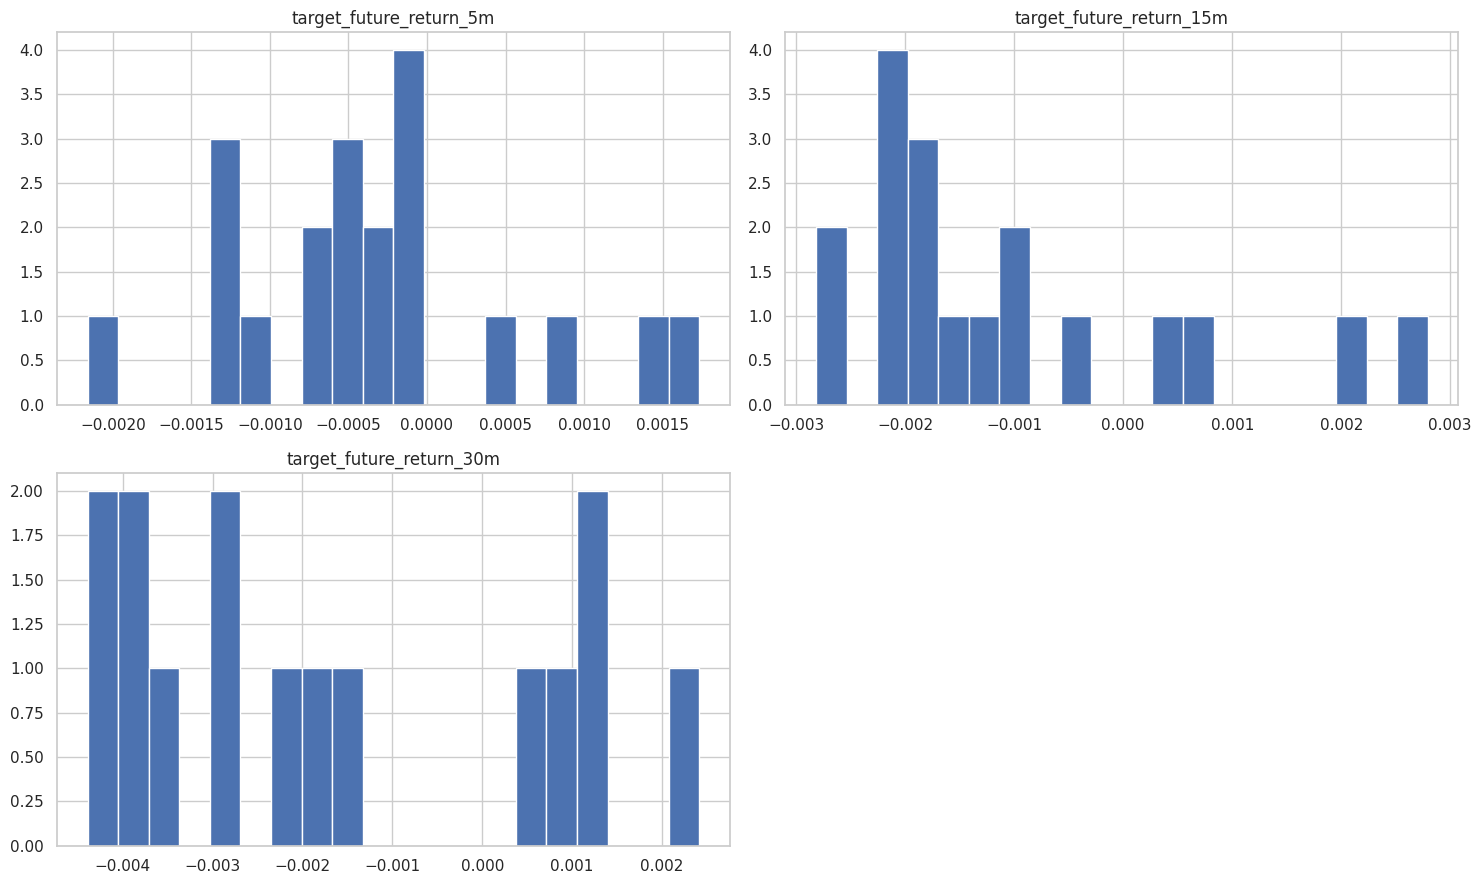

In [5]:
return_cols = [column for column in targets.columns if column.startswith("target_future_return_")]
fig, axes = plt.subplots(2, 1, figsize=(15, 9))
targets[return_cols].plot(ax=axes[0], marker="o")
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("Forward Log Return Targets")
targets[return_cols].hist(ax=axes[1], bins=20)
axes[1].set_title("Forward Return Distributions")
plt.tight_layout()

## Future Realized Volatility Targets

/tmp/ipykernel_484127/3719217901.py:5: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  targets[rv_target_cols].hist(ax=axes[1], bins=20)


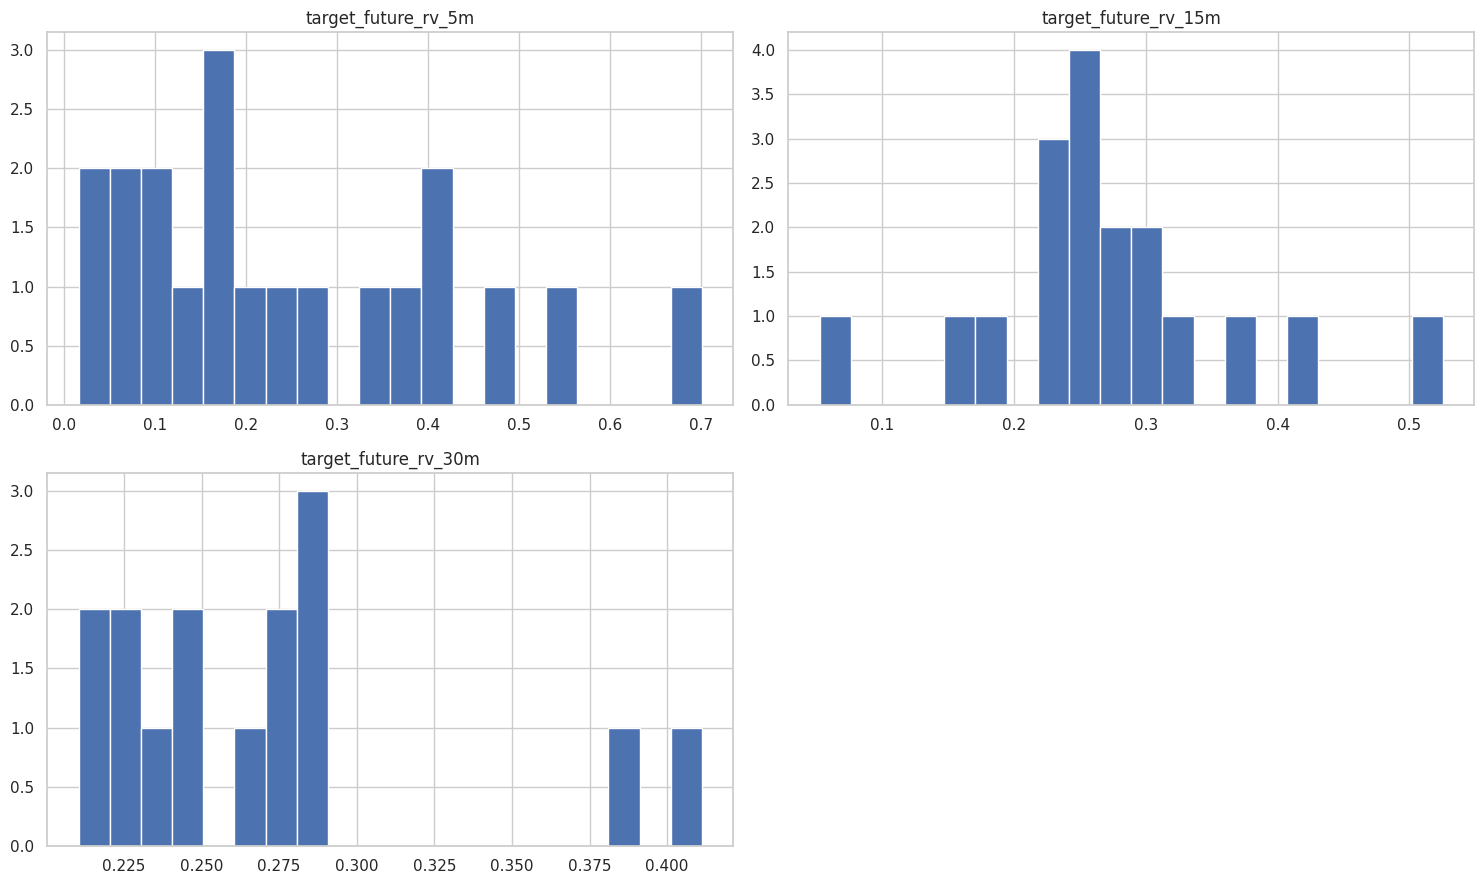

In [6]:
rv_target_cols = [column for column in targets.columns if column.startswith("target_future_rv_")]
fig, axes = plt.subplots(2, 1, figsize=(15, 9))
targets[rv_target_cols].plot(ax=axes[0], marker="o")
axes[0].set_title("Forward Realized Volatility Targets")
targets[rv_target_cols].hist(ax=axes[1], bins=20)
axes[1].set_title("Forward RV Distributions")
plt.tight_layout()

## VRP Targets

/tmp/ipykernel_484127/1426500540.py:6: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  targets[vrp_cols].hist(ax=axes[1], bins=20)


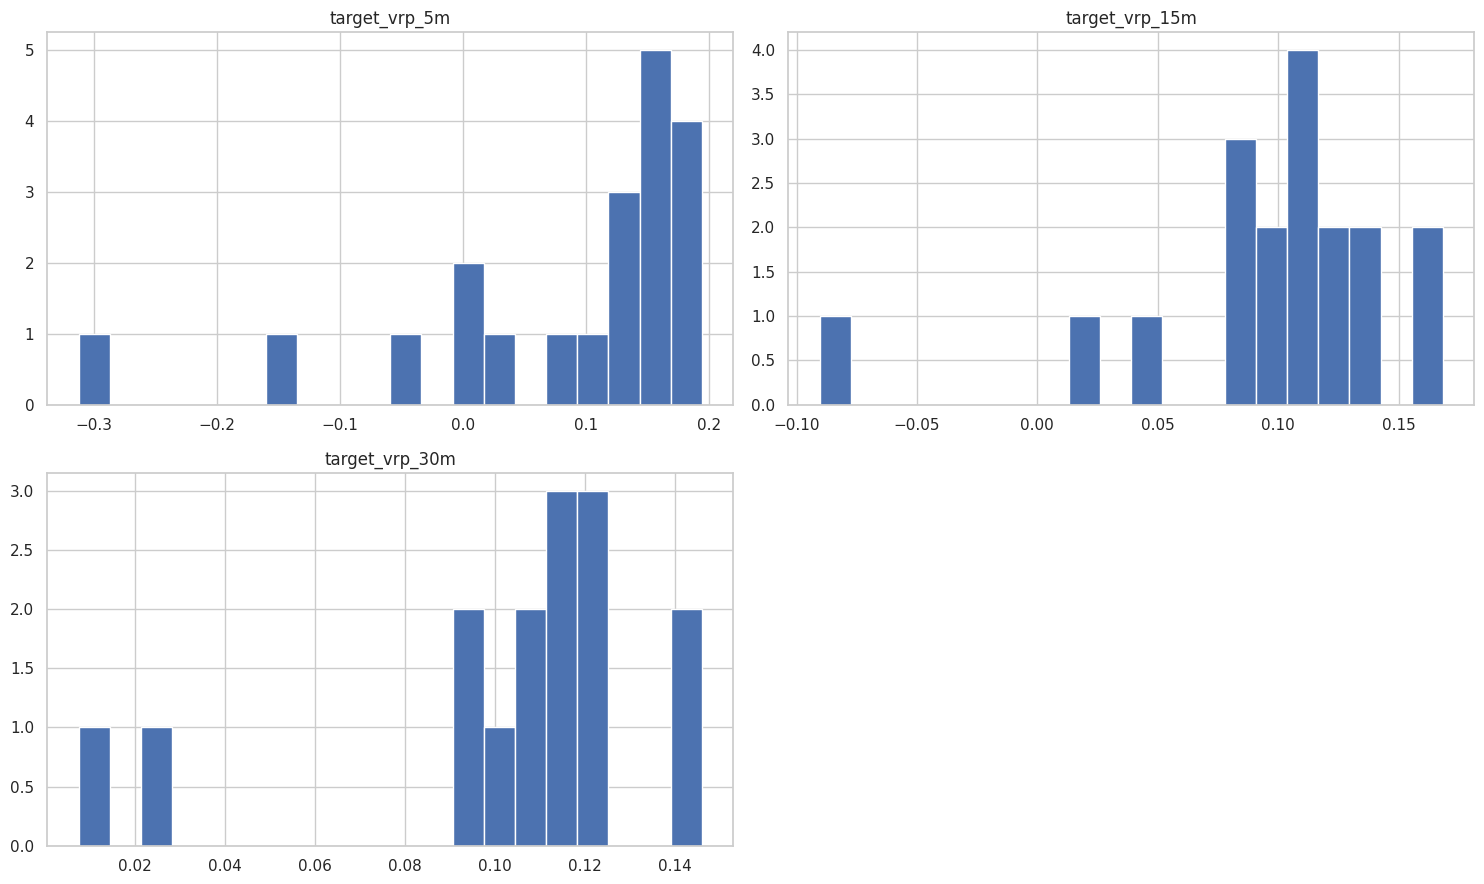

In [7]:
vrp_cols = [column for column in targets.columns if column.startswith("target_vrp_")]
fig, axes = plt.subplots(2, 1, figsize=(15, 9))
targets[vrp_cols].plot(ax=axes[0], marker="o")
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("VRP Targets: Short Implied Variance Minus Future Realized Variance")
targets[vrp_cols].hist(ax=axes[1], bins=20)
axes[1].set_title("VRP Target Distributions")
plt.tight_layout()

## FIR Execution Return Targets
These targets estimate the log PnL from entering after the current bar and exiting through a smoothed future execution schedule.

In [8]:
fir_cols = [column for column in targets.columns if column.startswith("target_fir_return_")]
fir_cols

['target_fir_return_entry5m_wait0m_exit15m',
 'target_fir_return_entry5m_wait0m_exit30m',
 'target_fir_return_entry5m_wait0m_exit60m',
 'target_fir_return_entry15m_wait15m_exit30m',
 'target_fir_return_entry30m_wait30m_exit60m']

/tmp/ipykernel_484127/803602448.py:6: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  targets[fir_cols].hist(ax=axes[1], bins=20)


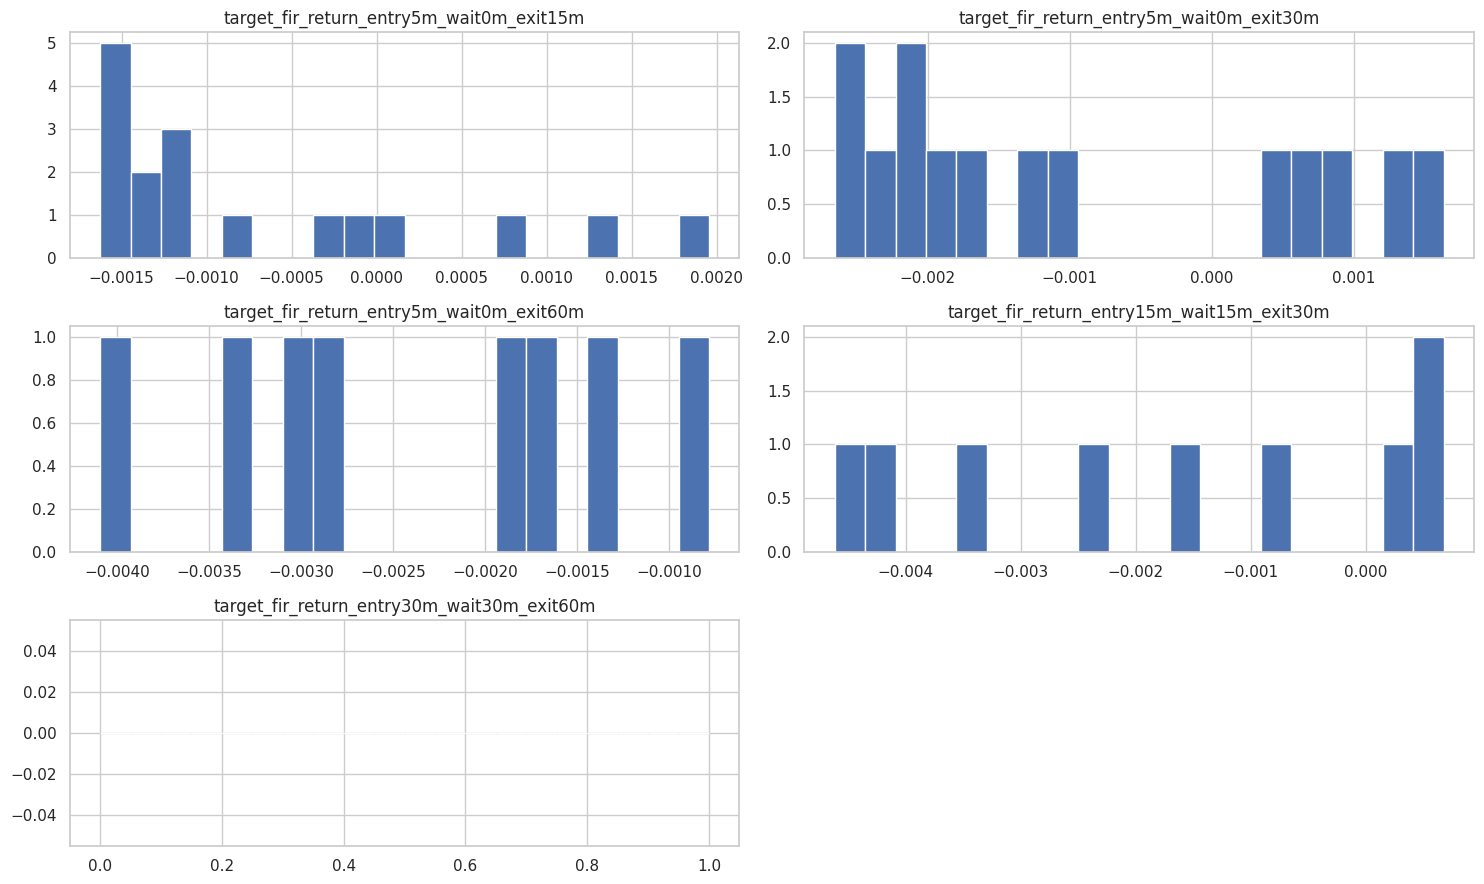

In [9]:
if fir_cols:
    fig, axes = plt.subplots(2, 1, figsize=(15, 9))
    targets[fir_cols].plot(ax=axes[0], marker="o")
    axes[0].axhline(0, color="black", linewidth=1)
    axes[0].set_title("FIR Execution-Weighted Forward Return Targets")
    targets[fir_cols].hist(ax=axes[1], bins=20)
    axes[1].set_title("FIR Target Distributions")
    plt.tight_layout()
else:
    print("No FIR targets available")

## Target Availability

In [10]:
availability = pd.DataFrame({"non_null": targets.notna().sum(), "null": targets.isna().sum(), "coverage": targets.notna().mean()}).sort_values("coverage", ascending=False)
availability

,non_null,null,coverage
target_future_return_5m,20,1,0.952381
target_future_rv_5m,20,1,0.952381
target_vrp_5m,20,1,0.952381
target_future_return_15m,18,3,0.857143
target_future_rv_15m,18,3,0.857143
target_vrp_15m,18,3,0.857143
target_fir_return_entry5m_wait0m_exit15m,17,4,0.809524
target_future_return_30m,15,6,0.714286
target_future_rv_30m,15,6,0.714286
target_vrp_30m,15,6,0.714286


## Optional Save

In [11]:
if SAVE_OUTPUTS:
    out_dir = FEATURE_ROOT / DATE / f"bar_{BAR_MINUTES}m"
    out_dir.mkdir(parents=True, exist_ok=True)
    targets.to_parquet(out_dir / "targets.parquet")
    print(f"wrote targets to {out_dir}")
else:
    print("SAVE_OUTPUTS is false; nothing written")

SAVE_OUTPUTS is false; nothing written
